## COMP1886 Machine Learning  Coursework

## Student ID: 001509687

In [2]:
# EDA #1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [3]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [4]:

employees = pd.read_excel('COMP 1886 - Coursework Dataset.xlsx', sheet_name='Employees (Industry)', skiprows=4)

mean_pay = pd.read_excel('COMP 1886 - Coursework Dataset.xlsx', sheet_name='Mean Pay (industry)', skiprows=4)


In [5]:
print("="*80)
print("TASK 2: EXPLORATORY DATA ANALYSIS")
print("="*80)
print(f"\n✅ Employees data shape: {employees.shape}")
print(f"✅ Mean Pay data shape: {mean_pay.shape}")

TASK 2: EXPLORATORY DATA ANALYSIS

✅ Employees data shape: (134, 22)
✅ Mean Pay data shape: (133, 24)


In [6]:
print("\n" + "="*80)
print("EDA #1: SECTORAL WAGE INEQUALITY ANALYSIS")
print("="*80)


EDA #1: SECTORAL WAGE INEQUALITY ANALYSIS


In [7]:
dates = mean_pay.iloc[:,0]

In [8]:
finance_col = [col for col in mean_pay.columns if 'Finance' in str(col) or 'insurance' in str(col)]
if finance_col:
    finance_wages = mean_pay[finance_col[0]]
else:
    finance_wages = mean_pay.iloc[:,10]
    plt.figure(figsize=(12,6))

<Figure size 1200x600 with 0 Axes>

In [9]:
accomodation_col = [col for col in mean_pay.columns if 'Accounting' in str(col) or 'food' in str(col)]
if accomodation_col:
    accomodation_wages = mean_pay[accomodation_col[0]]
else:
    accomodation_wages = mean_pay.iloc[:,5]


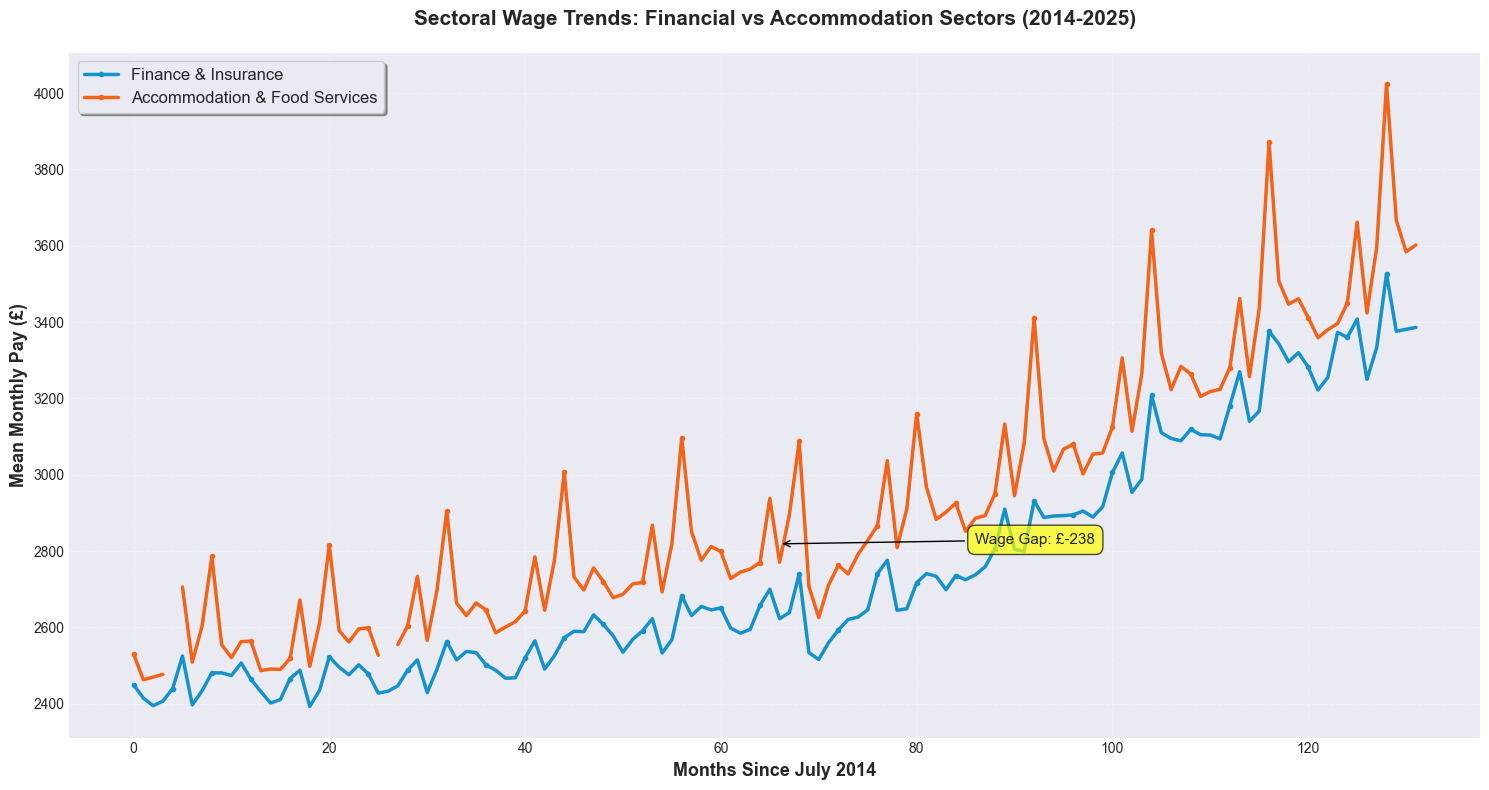

In [10]:
# Convert wage values to numeric, skipping the header row (index 0)
finance_wages_numeric = pd.to_numeric(finance_wages[1:], errors='coerce')
dates_no_header = dates[1:]

fig, ax = plt.subplots(figsize=(15,8))

ax.plot(range(len(dates_no_header)), finance_wages_numeric, 
        label='Finance & Insurance',
        linewidth=2.5, 
        color="#1592C8", 
        marker='o',
        markersize=3,
        markevery=4)

ax.plot(range(len(dates_no_header)), accomodation_wages[1:], 
        label='Accommodation & Food Services',
        linewidth=2.5,
        color="#F26419",
        marker='o',
        markersize=3,
        markevery=4)

ax.set_xlabel('Months Since July 2014', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Monthly Pay (£)', fontsize=13, fontweight='bold')
ax.set_title('Sectoral Wage Trends: Financial vs Accommodation Sectors (2014-2025)', 
             fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='upper left', frameon=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--')

mid_point = len(dates) // 2
gap = finance_wages.iloc[mid_point] - accomodation_wages.iloc[mid_point]
ax.annotate(f'Wage Gap: £{gap:.0f}', 
            xy=(mid_point, (finance_wages.iloc[mid_point] + accomodation_wages.iloc[mid_point])/2),
            xytext=(mid_point + 20, (finance_wages.iloc[mid_point] + accomodation_wages.iloc[mid_point])/2),
            fontsize=11,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color='black'))

plt.tight_layout()
plt.savefig('task2_eda1_plot1_wage_trends.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# Use the numeric versions for calculations (skip the header row)
finance_start = finance_wages_numeric.iloc[0]
finance_end = finance_wages_numeric.iloc[-1]
finance_growth = ((finance_end / finance_start) - 1) * 100

accomodation_wages_numeric = pd.to_numeric(accomodation_wages[1:], errors='coerce')
accommodation_start = accomodation_wages_numeric.iloc[0]
accommodation_end = accomodation_wages_numeric.iloc[-1]
accommodation_growth = ((accommodation_end / accommodation_start) - 1) * 100

print(f"\n📊 Financial Sector:")
print(f"   Starting wage: £{finance_start:.2f}")
print(f"   Ending wage: £{finance_end:.2f}")
print(f"   Growth: {finance_growth:.2f}%")

print(f"\n📊 Accommodation Sector:")
print(f"   Starting wage: £{accommodation_start:.2f}")
print(f"   Ending wage: £{accommodation_end:.2f}")
print(f"   Growth: {accommodation_growth:.2f}%")


📊 Financial Sector:
   Starting wage: £2450.00
   Ending wage: £3386.00
   Growth: 38.20%

📊 Accommodation Sector:
   Starting wage: £2531.00
   Ending wage: £3602.00
   Growth: 42.32%


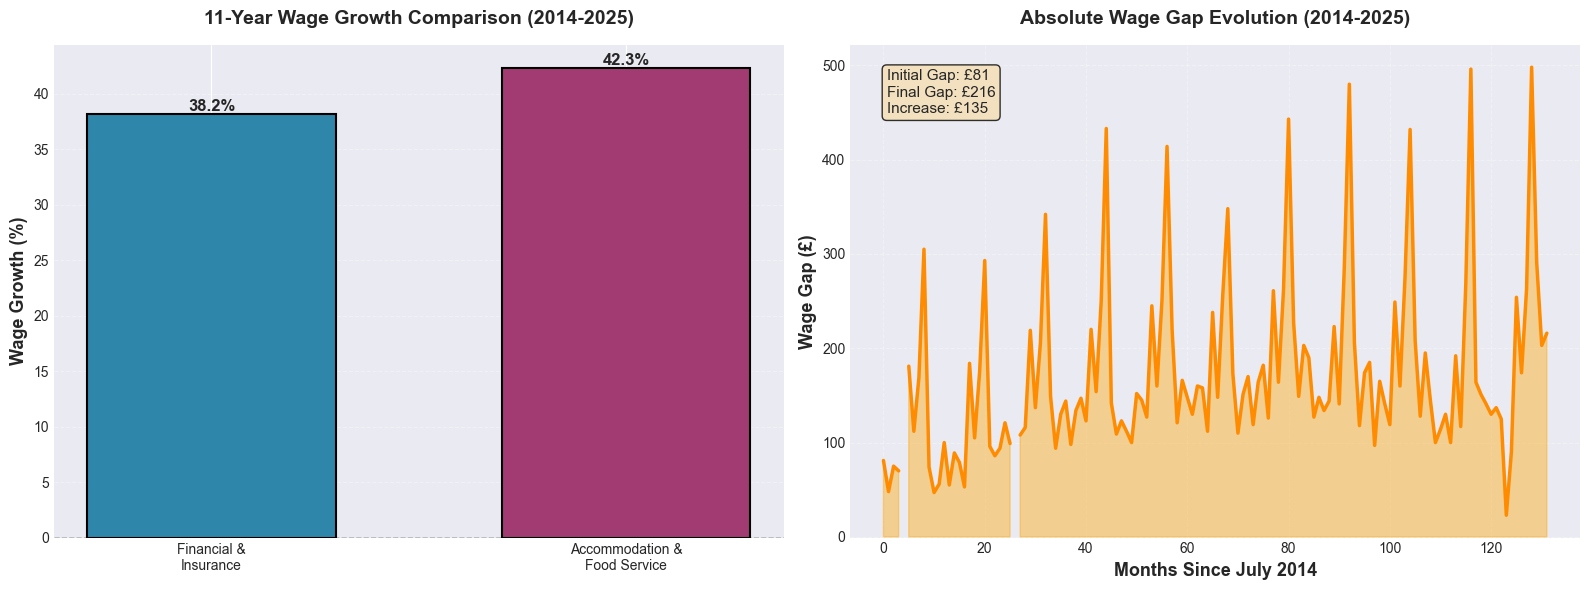


📈 Wage Gap Analysis:
   Initial gap (2014): £81.00
   Final gap (2025): £216.00
   Gap increase: £135.00 (166.7%)


In [26]:


# --- PLOT 2: Growth Rate and Wage Gap Analysis ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Growth rate comparison
sectors = ['Financial &\nInsurance', 'Accommodation &\nFood Service']
growth_rates = [finance_growth, accommodation_growth]
colors = ['#2E86AB', '#A23B72']

bars = ax1.bar(sectors, growth_rates, color=colors, width=0.6, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Wage Growth (%)', fontsize=13, fontweight='bold')
ax1.set_title('11-Year Wage Growth Comparison (2014-2025)', fontsize=14, fontweight='bold', pad=15)
ax1.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax1.grid(True, alpha=0.3, axis='y', linestyle='--')

# Add value labels on bars
for bar, value in zip(bars, growth_rates):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.1f}%',
             ha='center', va='bottom' if value > 0 else 'top',
             fontsize=12, fontweight='bold')

# Subplot 2: Absolute wage gap over time
# Use the numeric series (which skip the header row) to avoid subtracting strings
# finance_wages_numeric and accomodation_wages_numeric are defined earlier in the notebook
wage_gap_numeric = accomodation_wages_numeric.values - finance_wages_numeric.values

# x-axis aligns with dates_no_header (both skip header)
x = range(len(dates_no_header))
ax2.fill_between(x, wage_gap_numeric, alpha=0.4, color='orange', label='Wage Gap')
ax2.plot(x, wage_gap_numeric, linewidth=2.5, color='darkorange')
ax2.set_xlabel('Months Since July 2014', fontsize=13, fontweight='bold')
ax2.set_ylabel('Wage Gap (£)', fontsize=13, fontweight='bold')
ax2.set_title('Absolute Wage Gap Evolution (2014-2025)', fontsize=14, fontweight='bold', pad=15)
ax2.grid(True, alpha=0.3, linestyle='--')

# Ensure y-axis is upward (not inverted) by setting explicit limits with a small padding
valid_mask = ~np.isnan(wage_gap_numeric)
if np.any(valid_mask):
    y_min = float(np.nanmin(wage_gap_numeric))
    y_max = float(np.nanmax(wage_gap_numeric))
    if y_max == y_min:
        pad = abs(y_max) * 0.05 if y_max != 0 else 1.0
    else:
        pad = (y_max - y_min) * 0.05
    # Ensure y_min is less than y_max and set limits so that larger values are at the top
    ax2.set_ylim(y_min - pad, y_max + pad)

# Add statistics
gap_start = float(wage_gap_numeric[0])
gap_end = float(wage_gap_numeric[-1])
gap_increase = gap_end - gap_start
ax2.text(0.05, 0.95, f'Initial Gap: £{gap_start:.0f}\nFinal Gap: £{gap_end:.0f}\nIncrease: £{gap_increase:.0f}',
         transform=ax2.transAxes, fontsize=11,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('task2_eda1_plot2_growth_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📈 Wage Gap Analysis:")
print(f"   Initial gap (2014): £{gap_start:.2f}")
print(f"   Final gap (2025): £{gap_end:.2f}")
print(f"   Gap increase: £{gap_increase:.2f} ({(gap_increase/gap_start)*100:.1f}%)")


EDA #2: EMPLOYMENT VOLATILITY ANALYSIS


<Figure size 640x480 with 0 Axes>


📊 Employment Volatility (Coefficient of Variation):
   Accommodation & Food: 8.59%
   Healthcare & Social: 3.31%
   Volatility Ratio: 2.59x


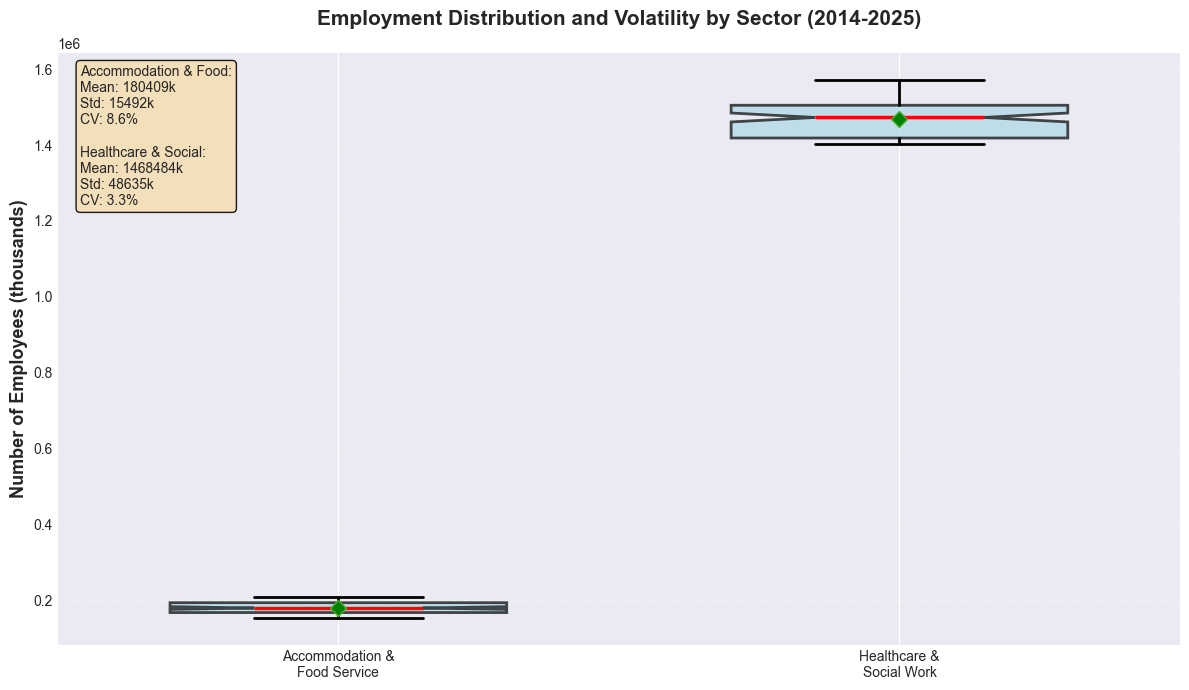


📉 COVID-19 Impact (March 2020 - June 2021):
   Accommodation sector employment drop: -0.8%
   Healthcare sector variation: ±5.5%
   Differential impact: 0.2x

✅ TASK 2 COMPLETE - All plots saved!

Generated files:
  1. task2_eda1_plot1_wage_trends.png
  2. task2_eda1_plot2_growth_comparison.png
  3. task2_eda2_plot1_employment_volatility.png
  4. task2_eda2_plot2_distribution_comparison.png


In [19]:

# ============================================================================
# EDA #2: EMPLOYMENT VOLATILITY DURING COVID-19
# ============================================================================

print("\n" + "="*80)
print("EDA #2: EMPLOYMENT VOLATILITY ANALYSIS")
print("="*80)

# Ensure pandemic start/end exist (do not overwrite if already defined)
if 'pandemic_start' not in globals():
    pandemic_start = 69
if 'pandemic_end' not in globals():
    pandemic_end = 84

# Extract employment data for volatile and stable sectors
accommodation_emp_col = [col for col in employees.columns if 'accommodation' in str(col).lower() or 'food' in str(col).lower()]
if accommodation_emp_col:
    accommodation_emp = employees[accommodation_emp_col[0]]
else:
    accommodation_emp = employees.iloc[:, 5]

healthcare_emp_col = [col for col in employees.columns if 'health' in str(col).lower() or 'social' in str(col).lower()]
if healthcare_emp_col:
    healthcare_emp = employees[healthcare_emp_col[0]]
else:
    healthcare_emp = employees.iloc[:, 15]

# Convert the extracted series to numeric, drop non-numeric rows (e.g. header) and align lengths
accommodation_emp = pd.to_numeric(accommodation_emp, errors='coerce').dropna().reset_index(drop=True)
healthcare_emp = pd.to_numeric(healthcare_emp, errors='coerce').dropna().reset_index(drop=True)

# Truncate both series to the same length to avoid shape mismatches when plotting
n = min(len(accommodation_emp), len(healthcare_emp))
accommodation_emp = accommodation_emp.iloc[:n]
healthcare_emp = healthcare_emp.iloc[:n]

# Use x covering the truncated length
x_plot = range(n)

# Plot time series (use existing ax if available)
ax.plot(x_plot, accommodation_emp, 
        label='Accommodation & Food Service', 
        linewidth=2.5, 
        color='#E63946',
        marker='o',
        markersize=3,
        markevery=6)

ax.plot(x_plot, healthcare_emp, 
        label='Healthcare & Social Work', 
        linewidth=2.5, 
        color='#06FFA5',
        marker='s',
        markersize=3,
        markevery=6)

# Highlight pandemic period if within plotted range
ps = max(0, int(pandemic_start))
pe = min(n - 1, int(pandemic_end))
if ps < pe:
    ax.axvspan(ps, pe, alpha=0.2, color='red', label='COVID-19 Lockdown Period')

ax.set_xlabel('Months Since July 2014', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Employees (thousands)', fontsize=13, fontweight='bold')
ax.set_title('Employment Volatility During COVID-19: Service vs Essential Sectors', 
             fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='best', frameon=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--')

# Add annotations for key events (guard against index errors)
try:
    if 1 <= pandemic_start < n-2:
        pre_covid_acc = accommodation_emp.iloc[pandemic_start-1]
        during_covid_acc = accommodation_emp.iloc[pandemic_start+2]
        drop = ((during_covid_acc - pre_covid_acc) / pre_covid_acc) * 100

        ax.annotate(f'Drop: {drop:.1f}%', 
                    xy=(pandemic_start+1, during_covid_acc),
                    xytext=(max(0, pandemic_start-10), during_covid_acc - (0.1 * during_covid_acc)),
                    fontsize=11,
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.8),
                    arrowprops=dict(arrowstyle='->', color='red', lw=2))
except Exception:
    pass

plt.tight_layout()
plt.savefig('task2_eda2_plot1_employment_volatility.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate volatility statistics
acc_cv = (np.std(accommodation_emp) / np.mean(accommodation_emp)) * 100
health_cv = (np.std(healthcare_emp) / np.mean(healthcare_emp)) * 100

print(f"\n📊 Employment Volatility (Coefficient of Variation):")
print(f"   Accommodation & Food: {acc_cv:.2f}%")
print(f"   Healthcare & Social: {health_cv:.2f}%")
print(f"   Volatility Ratio: {acc_cv/health_cv:.2f}x")

# --- PLOT 2: Box Plot Distribution Comparison ---
fig, ax = plt.subplots(figsize=(12, 7))

# Prepare data for box plot
data_to_plot = [accommodation_emp.dropna(), healthcare_emp.dropna()]
labels = ['Accommodation &\nFood Service', 'Healthcare &\nSocial Work']

bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, widths=0.6,
                notch=True, showmeans=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7, linewidth=2),
                whiskerprops=dict(linewidth=2),
                capprops=dict(linewidth=2),
                medianprops=dict(color='red', linewidth=2.5),
                meanprops=dict(marker='D', markerfacecolor='green', markersize=8))

ax.set_ylabel('Number of Employees (thousands)', fontsize=13, fontweight='bold')
ax.set_title('Employment Distribution and Volatility by Sector (2014-2025)', 
             fontsize=15, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

# Add statistics annotations
stats_text = f"Accommodation & Food:\nMean: {np.mean(accommodation_emp):.0f}k\nStd: {np.std(accommodation_emp):.0f}k\nCV: {acc_cv:.1f}%\n\nHealthcare & Social:\nMean: {np.mean(healthcare_emp):.0f}k\nStd: {np.std(healthcare_emp):.0f}k\nCV: {health_cv:.1f}%"

ax.text(0.02, 0.98, stats_text,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))

plt.tight_layout()
plt.savefig('task2_eda2_plot2_distribution_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate pandemic impact (guard indexes)
if 1 <= pandemic_start < n and pandemic_start < pandemic_end:
    pre_pandemic_acc = accommodation_emp.iloc[pandemic_start-1]
    lowest_pandemic_acc = accommodation_emp.iloc[pandemic_start: min(pandemic_end, n)].min()
    pandemic_drop = ((lowest_pandemic_acc - pre_pandemic_acc) / pre_pandemic_acc) * 100

    pre_pandemic_health = healthcare_emp.iloc[pandemic_start-1]
    health_slice = healthcare_emp.iloc[pandemic_start: min(pandemic_end, n)]
    if len(health_slice) > 0 and pre_pandemic_health != 0:
        variation_health = ((health_slice.max() - health_slice.min()) / pre_pandemic_health) * 100
    else:
        variation_health = np.nan

    print(f"\n📉 COVID-19 Impact (March 2020 - June 2021):")
    print(f"   Accommodation sector employment drop: {pandemic_drop:.1f}%")
    print(f"   Healthcare sector variation: ±{variation_health:.1f}%")
    if variation_health and not np.isnan(variation_health) and variation_health != 0:
        print(f"   Differential impact: {abs(pandemic_drop)/variation_health:.1f}x")

print("\n" + "="*80)
print("✅ TASK 2 COMPLETE - All plots saved!")
print("="*80)
print("\nGenerated files:")
print("  1. task2_eda1_plot1_wage_trends.png")
print("  2. task2_eda1_plot2_growth_comparison.png")
print("  3. task2_eda2_plot1_employment_volatility.png")
print("  4. task2_eda2_plot2_distribution_comparison.png")

In [24]:
# Check what columns exist
print("="*80)
print("COLUMNS IN MEAN PAY DATASET:")
print("="*80)
for i, col in enumerate(mean_pay.columns):
    print(f"Column {i}: {col}")

COLUMNS IN MEAN PAY DATASET:
Column 0: Unnamed: 0
Column 1: Unnamed: 1
Column 2: Unnamed: 2
Column 3: Unnamed: 3
Column 4: Unnamed: 4
Column 5: Unnamed: 5
Column 6: Unnamed: 6
Column 7: Unnamed: 7
Column 8: Unnamed: 8
Column 9: Unnamed: 9
Column 10: Unnamed: 10
Column 11: Unnamed: 11
Column 12: Unnamed: 12
Column 13: Unnamed: 13
Column 14: Unnamed: 14
Column 15: Unnamed: 15
Column 16: Unnamed: 16
Column 17: Unnamed: 17
Column 18: Unnamed: 18
Column 19: Unnamed: 19
Column 20: Unnamed: 20
Column 21: Unnamed: 21
Column 22: Unnamed: 22
Column 23: Unnamed: 23
